# Pupil saccades — ACUTEVIS (DLC pupil landmarks)

Goal: detect saccades from the **position** of the pupil, which the ACUTEVIS dataset pickle does not keep
(datakit's `PupilDLCSource` collapses the 8 DLC landmarks into one diameter and drops the coordinates).
So this notebook goes back to the DeepLabCut `.h5` outputs.

1. **Load** the DLC `.h5` files for the three ACUTEVIS DLC projects.
2. **Centroid** — an explicit, dropout-robust estimate of the pupil centre from the 8 circumference points
   (plus the 4 diameters).
3. **Visual check** — landmarks + computed centroid drawn on the raw video frames.

Main output: **`centroids`**, one long DataFrame indexed by `(subject, session, task, frame)` with a `condition` column.
Restrict what gets loaded with `TASKS` / `SUBJECTS` / `CONDITIONS` in the first cell, or slice any table afterwards with
`select(...)`.

**Running without D:.** Section 4 saves everything this analysis needs to `C:\Projects\ACUTEVIS\pupil_centroids.pkl`:
sessions + condition, the raw DLC landmarks, centroids, diameters, QC and parameters. With `USE_CACHE = True` the notebook
reads from that pickle and recomputes the centroids from its landmarks, so D: is only needed for the raw videos in the
visual check (80 GB, not copied). Without them the check draws the landmarks on a blank background.

Kernel: the `dev` conda env (`C:\Users\sturt\.conda\envs\dev`) — it has `pytables` (needed by `pd.read_hdf`) and `opencv`.
The `datadori` env does **not** have `pytables`.

In [1]:
from pathlib import Path
import re
import warnings

import cv2
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DLC_ROOT = Path(r"D:\Projects\ACUTEVIS\processed\pupil")
DLC_PROJECTS = [
    "ACUTEVIS06_09-SSB-2025-07-25",
    "ACUTEVIS10_13-SSB-2025-09-24",
    "ACUTEVIS14_17-SSB-2025-10-21",
]
DATA_ROOT = Path(r"D:\Projects\ACUTEVIS\data")   # raw session folders; configuration.csv holds `injection`

CACHE_PATH = Path(r"C:\Projects\ACUTEVIS\pupil_centroids.pkl")
USE_CACHE = True    # True: read sessions + landmarks from CACHE_PATH when it exists (no D: needed)
                    # False: always re-read the DLC .h5 files and configuration.csv from D:

# ---- Which sessions to load (None = all). Anything filtered out here is never read from disk. ----
TASKS = None        # e.g. ["task-gratings"] or ["task-movies"]
SUBJECTS = None     # e.g. ["ACUTEVIS06", "ACUTEVIS14"]
CONDITIONS = None   # subset of CONDITION_ORDER, e.g. ["baseline", "high"]
CONDITION_ORDER = ["baseline", "saline", "low", "high"]

P_CUTOFF = 0.7      # DLC likelihood gate (same as datakit PupilDLCSource.confidence_threshold)
PX_PER_MM = 53.6    # datakit PupilDLCSource.pixel_to_mm (pixels per mm)
RADIAL_TOL = 0.35   # drop a confident point whose radius is >35% off the frame's median radius

# Landmark k (0-based) -> position on the pupil, verified from the labeled data below.
LANDMARK_LABELS = ["top", "bottom", "right", "left",
                   "upper-right", "lower-left", "lower-right", "upper-left"]
NOMINAL_ANGLE = np.array([90, -90, 0, 180, 45, -135, -45, 135])  # deg, 0 = right, 90 = up
OPPOSITE_PAIRS = [(0, 1), (2, 3), (4, 5), (6, 7)]
PAIR_NAMES = ["vert", "horiz", "diag1", "diag2"]   # diag1 = UR-LL ("/"), diag2 = LR-UL ("\")

## 1. Load the DLC `.h5` files

Each project's `videos/` folder holds one `*_pupilDLC_*.h5` per session (the model's predictions on the full video)
next to the raw `*_pupil.mp4`. The `labeled-data/` and `evaluation-results*/` `.h5` files are training/eval
artefacts and are skipped. Expect **88 sessions** (44 gratings + 44 movies; grayscreen was not run through these projects).

The injection condition comes from each session's `configuration.csv` in `D:\Projects\ACUTEVIS\data`, matched on the
recording timestamp. **Session number does not equal condition across cohorts.** ACUTEVIS06–13 ran
baseline → saline → high → low, and ACUTEVIS14–17 ran baseline → low → saline → high. So always filter or group on
`condition`, never on `ses-0N`.

In [2]:
FNAME_RE = re.compile(r"(?P<stamp>\d{8}_\d{6})_sub-(?P<subject>[^_]+)_(?P<session>ses-\d+)"
                      r"_(?P<task>task-[^_]+)_pupilDLC_")


def read_condition(subject, session, stamp):
    '''`injection` from the session's configuration.csv, preferring the file with the same recording timestamp.'''
    folder = DATA_ROOT / f"sub-{subject}" / session
    configs = sorted(folder.glob(f"{stamp}_*_configuration.csv")) or sorted(folder.glob("*_configuration.csv"))
    values = {pd.read_csv(f, index_col="Parameter")["Value"].get("injection") for f in configs}
    if len(values) != 1:
        warnings.warn(f"{subject} {session}: injection = {values or 'no configuration.csv'}")
        return None
    return values.pop()


def select(df, task=None, subject=None, session=None, condition=None):
    '''Rows of `df` matching every given filter; each filter is a value, a list of values, or None (no filter).

    Works on any table in this notebook (`sessions`, `centroids`, `qc`): each name is looked up as an
    index level first, then as a column.
    '''
    keep = np.ones(len(df), dtype=bool)
    for name, wanted in {"task": task, "subject": subject, "session": session, "condition": condition}.items():
        if wanted is None:
            continue
        wanted = [wanted] if isinstance(wanted, str) else list(wanted)
        values = df.index.get_level_values(name) if name in df.index.names else df[name]
        keep &= np.asarray(pd.Index(values).isin(wanted))
    return df[keep]


def discover_sessions():
    '''Session table from the DLC project folders on D: (one row per *_pupilDLC_*.h5).'''
    rows = []
    for project in DLC_PROJECTS:
        for h5 in sorted((DLC_ROOT / project / "videos").glob("*_pupilDLC_*.h5")):
            m = FNAME_RE.search(h5.name)
            if m is None:
                print("skipping unparsed file:", h5.name)
                continue
            mp4 = h5.with_name(h5.name.split("DLC_")[0] + ".mp4")
            rows.append({**m.groupdict(), "project": project, "h5": str(h5),
                         "mp4": str(mp4) if mp4.exists() else None})
    table = pd.DataFrame(rows)
    table["condition"] = pd.Categorical(
        [read_condition(r.subject, r.session, r.stamp) for r in table.itertuples()],
        categories=CONDITION_ORDER, ordered=True)
    table = table.set_index(["subject", "session", "task"]).sort_index()
    assert table.index.is_unique, "duplicate (subject, session, task) across projects"
    return table


from_cache = USE_CACHE and CACHE_PATH.exists()
if from_cache:
    cache = pd.read_pickle(CACHE_PATH)
    all_sessions = cache["sessions"]
    print(f"reading from {CACHE_PATH} (created {cache['params']['created']})")
else:
    all_sessions = discover_sessions()
    print(f"reading DLC output from {DLC_ROOT}")

sessions = select(all_sessions, task=TASKS, subject=SUBJECTS, condition=CONDITIONS)
print(f"{len(sessions)} of {len(all_sessions)} sessions selected "
      f"(TASKS={TASKS}, SUBJECTS={SUBJECTS}, CONDITIONS={CONDITIONS}); "
      f"{sessions.condition.isna().sum()} without a condition, {sessions.mp4.isna().sum()} without a raw mp4")

# which session number holds which condition, per subject
sessions.reset_index().pivot_table(index="subject", columns=["task", "condition"], values="session",
                                   aggfunc="first", observed=True)

reading DLC output from D:\Projects\ACUTEVIS\processed\pupil
88 of 88 sessions selected (TASKS=None, SUBJECTS=None, CONDITIONS=None); 0 without a condition, 0 without a raw mp4


task       task-gratings                         task-movies                  \
condition       baseline  saline     low    high    baseline  saline     low   
subject                                                                        
ACUTEVIS06        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS07        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS09        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS10        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS11        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS12        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS13        ses-01  ses-02  ses-04  ses-03      ses-01  ses-02  ses-04   
ACUTEVIS14        ses-01  ses-03  ses-02  ses-04      ses-01  ses-03  ses-02   
ACUTEVIS15        ses-01  ses-03  ses-02  ses-04      ses-01  ses-03  ses-02   
ACUTEVIS16        ses-01  ses-03  ses-02  ses-04      ses-01  ses-03  ses-02   
ACUTEVIS17        ses-01  ses-03  ses-02  ses-04      ses-01  ses-03  ses-02   

task                
condition     high  
subject             
ACUTEVIS06  ses-03  
ACUTEVIS07  ses-03  
ACUTEVIS09  ses-03  
ACUTEVIS10  ses-03  
ACUTEVIS11  ses-03  
ACUTEVIS12  ses-03  
ACUTEVIS13  ses-03  
ACUTEVIS14  ses-04  
ACUTEVIS15  ses-04  
ACUTEVIS16  ses-04  
ACUTEVIS17  ses-04

In [3]:
def load_dlc_h5(path):
    '''Read one single-animal DLC .h5.

    Returns
    -------
    xy : (n_frames, 8, 2) float   pixel coords, x to the right, y DOWN (image convention)
    lk : (n_frames, 8) float      DLC likelihood per landmark
    bodyparts : list[str]

    Bodyparts are ordered by their trailing number, so index k is landmark k+1 whether the
    project named them 'pupil-01' (ACUTEVIS06_09) or 'pupil1' (ACUTEVIS10_13, 14_17).
    '''
    df = pd.read_hdf(path)
    df = df[df.columns.get_level_values(0)[0]]          # drop the scorer level
    bodyparts = sorted(df.columns.get_level_values(0).unique(),
                       key=lambda b: int(re.search(r"(\d+)$", b).group(1)))
    xy = np.stack([df[bp][["x", "y"]].to_numpy(float) for bp in bodyparts], axis=1)
    lk = np.stack([df[bp]["likelihood"].to_numpy(float) for bp in bodyparts], axis=1)
    return xy, lk, bodyparts


LANDMARK_COLUMNS = pd.MultiIndex.from_product([range(1, 9), ["x", "y", "likelihood"]],
                                              names=["landmark", "coord"])

dlc = {}
if from_cache:
    landmarks = cache.pop("landmarks")
    assert landmarks.columns.equals(LANDMARK_COLUMNS)
    for key in sessions.index:
        arr = landmarks.loc[key].to_numpy().reshape(-1, 8, 3)       # (frames, landmark, x/y/likelihood)
        dlc[key] = {"xy": arr[..., :2].copy(), "lk": arr[..., 2].copy()}
    del cache, landmarks
else:
    for key, row in sessions.iterrows():
        xy, lk, bodyparts = load_dlc_h5(row.h5)
        assert len(bodyparts) == 8, (key, bodyparts)
        dlc[key] = {"xy": xy, "lk": lk}

n_conf = {k: (v["lk"] >= P_CUTOFF).sum(1) for k, v in dlc.items()}
load_summary = pd.DataFrame({
    "n_frames":   {k: len(n) for k, n in n_conf.items()},
    "all_8_conf": {k: (n == 8).mean() for k, n in n_conf.items()},
    "lt_4_conf":  {k: (n < 4).mean() for k, n in n_conf.items()},
    "median_lk":  {k: np.median(v["lk"]) for k, v in dlc.items()},
})
print(f"loaded {len(dlc)} sessions; fraction of frames with all 8 points >= {P_CUTOFF}:")
print(load_summary.all_8_conf.describe().round(4).to_string())
load_summary.sort_values("all_8_conf").head(8).round(4)

loaded 88 sessions; fraction of frames with all 8 points >= 0.7:
count    88.0000
mean      0.9885
std       0.0167
min       0.9066
25%       0.9870
50%       0.9946
75%       0.9981
max       1.0000


,,,n_frames,all_8_conf,lt_4_conf,median_lk
ACUTEVIS12,ses-01,task-movies,12400,0.9066,0.0004,0.9243
ACUTEVIS11,ses-03,task-movies,12500,0.9279,0.0058,0.9229
ACUTEVIS13,ses-02,task-gratings,12500,0.9362,0.0001,0.8857
ACUTEVIS12,ses-01,task-gratings,12000,0.9466,0.0012,0.9277
ACUTEVIS11,ses-01,task-gratings,12800,0.9523,0.0004,0.9150
ACUTEVIS10,ses-02,task-movies,12500,0.9533,0.0014,0.9219
ACUTEVIS07,ses-02,task-movies,12600,0.9652,0.0057,0.9473
ACUTEVIS13,ses-03,task-movies,12500,0.9658,0.0006,0.9155


### Landmark geometry (verified, not assumed)

The centroid method below depends on which landmarks sit **opposite** each other. From the hand labels in all three
projects (1,757 labeled frames), the layout is identical:

| landmark | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 |
|---|---|---|---|---|---|---|---|---|
| position | top | bottom | right | left | upper-right | lower-left | lower-right | upper-left |

so the opposite pairs are **(1,2) vertical, (3,4) horizontal, (5,6) "/" diagonal, (7,8) "\\" diagonal** —
the same pairs datakit uses for its 4 diameters. The cell below re-checks this on the model predictions for every session.

In [4]:
def landmark_angles(xy, lk):
    '''Circular-mean angle (deg, 0 = right, 90 = up) of each landmark around the frame centre.'''
    full = (lk >= P_CUTOFF).all(1)
    d = xy[full] - xy[full].mean(1, keepdims=True)
    z = np.exp(1j * np.arctan2(-d[..., 1], d[..., 0]))     # minus: image y points down
    return np.degrees(np.angle(z.mean(0)))


def ang_diff(a, b):
    return np.abs((a - b + 180) % 360 - 180)


angles = pd.DataFrame({k: landmark_angles(v["xy"], v["lk"]) for k, v in dlc.items()}).T
angles.columns = [f"{i + 1}:{lab}" for i, lab in enumerate(LANDMARK_LABELS)]

off_nominal = ang_diff(angles.to_numpy(), NOMINAL_ANGLE)
pair_sep = np.stack([ang_diff(angles.iloc[:, a], angles.iloc[:, b]) for a, b in OPPOSITE_PAIRS], 1)
print(f"max deviation from nominal angle: {off_nominal.max():.1f} deg")
print(f"opposite-pair separation: min {pair_sep.min():.1f}, median {np.median(pair_sep):.1f} deg (ideal 180)")
assert off_nominal.max() < 25 and pair_sep.min() > 155, "landmark layout differs from the assumed one"

# signed deviation from the nominal angle, per landmark across sessions (avoids the +/-180 wrap of "left")
deviation = (angles - NOMINAL_ANGLE + 180) % 360 - 180
deviation.describe().loc[["mean", "std", "min", "max"]].round(1)

max deviation from nominal angle: 10.3 deg
opposite-pair separation: min 172.2, median 178.0 deg (ideal 180)


,1:top,2:bottom,3:right,4:left,5:upper-right,6:lower-left,7:lower-right,8:upper-left
mean,-1.1,-2.7,-0.7,3.0,0.1,-1.1,-1.4,0.3
std,1.9,2.8,1.8,2.4,2.4,2.4,2.2,2.6
min,-5.9,-9.7,-6.8,-3.4,-7.0,-7.5,-6.2,-6.2
max,4.0,3.1,4.8,10.3,8.8,5.2,4.6,6.3


## 2. Pupil centroid from the 8 circumference points

Notation, per frame: landmark positions $p_i = (x_i, y_i)$ in pixels, DLC likelihoods $\ell_i$, $i = 1..8$;
opposite pairs $J = \{(1,2), (3,4), (5,6), (7,8)\}$.

### Why not just average the points?
With all 8 points present, the plain mean $\bar p = \tfrac18\sum_i p_i$ is fine. But if point $k$ is dropped, the mean of the
remaining 7 is

$$\bar p_{(-k)} = \frac{8c - p_k}{7} = c + \frac{c - p_k}{7},$$

i.e. it **jumps by $R/7$ away from the missing point** ($R$ = pupil radius). Here $R \approx 45$–$60$ px, so a single
dropout moves the "centroid" by ~7–9 px, while the typical frame-to-frame movement of the centre is ~0.3 px.
Every flicker in DLC confidence would look like a saccade. The method below is built to avoid that.

### The method

**Step 1 — confidence gate.** $v_i = [\ell_i \ge 0.7]$.

**Step 2 — geometric gate.** DLC likelihood is not a guarantee: a point can be confidently placed on the eyelid edge or a
corneal reflection. Take a provisional centre $c_0$ (median of the valid pair midpoints if $\ge 2$ pairs are valid,
otherwise the mean of valid points), radii $r_i = \lVert p_i - c_0\rVert$ and their median $\tilde R$ over valid points.
Drop point $i$ if $|r_i - \tilde R| > 0.35\,\tilde R$. Call the survivors $u_i$.

**Step 3 — pair gate.** A pair $(a,b)$ is usable only if **both** ends survive: $J^* = \{(a,b)\in J : u_a \wedge u_b\}$.
If one end of a pair is lost, its partner is set aside too. That keeps the remaining points symmetric about the centre.

**Step 4 — centre = mean of the opposite-pair midpoints**

$$c = \frac{1}{|J^*|}\sum_{(a,b)\in J^*} \frac{p_a + p_b}{2}, \qquad |J^*| \ge 2.$$

*Why this is the centre, even for an elliptical (obliquely viewed) pupil:* an ellipse is centrally symmetric — every chord
through its centre is bisected by it, and the extreme point in any direction (top) is diametrically opposite the
extreme point in the reverse direction (bottom). Each labeled pair is such an opposite pair, so each midpoint is an
estimate of $c$ itself, and losing whole pairs does not bias the average. (Residual error comes only from DLC placing
a pair slightly off-antipodal; when all 8 points are present this equals the plain mean.)

**Fallbacks** (each frame records which one was used in `method`):

| `method` | condition | centre |
|---|---|---|
| `pairs` | $\ge 2$ usable pairs | Step 4 |
| `ellipse` | $< 2$ pairs, $\ge 5$ usable points, points surround the centre* | centre of the least-squares ellipse through the usable points (`cv2.fitEllipse`, Fitzgibbon) |
| `circle` | $< 2$ pairs, 3–4 usable points, points surround the centre* | algebraic circle fit: solve $x^2+y^2 + Dx + Ey + F = 0$ by least squares, $c = (-D/2,\,-E/2)$ — assumes a round pupil, least trustworthy |
| `one_pair` | exactly 2 usable points that form a pair | that pair's midpoint |
| `none` | otherwise (blink, eye closed, points bunched on one side) | NaN — never interpolated here |

\*"Surround the centre": the largest angular gap between usable landmarks (using their nominal angles) is $< 180°$.
A curve fitted to points that all sit on one arc (e.g. only the top-left points visible as the lid closes) can put
the centre almost anywhere along that arc's axis, so those frames are reported as `none` instead of guessed.

**Cross-check:** an ellipse fit is also run on *every* frame with $\ge 5$ usable points (`ell_cx`, `ell_cy`).
It is an independent estimate of the same centre, so the distance between the two shows how precise the centroid is.

**Diameters:** $d_j = \lVert p_a - p_b\rVert$ for each usable pair (`d_vert_px` …), and
`diameter_mm` = mean over usable pairs / 53.6 px·mm⁻¹. That matches datakit's definition, except datakit interpolates
over missing frames; here they stay NaN.

In [5]:
_PA, _PB = np.array(OPPOSITE_PAIRS).T
METHODS = ["pairs", "ellipse", "circle", "one_pair", "none"]


def fit_circle_center(pts):
    '''Kasa algebraic circle fit: least squares on x^2 + y^2 + D x + E y + F = 0.'''
    A = np.column_stack([pts[:, 0], pts[:, 1], np.ones(len(pts))])
    D, E, _ = np.linalg.lstsq(A, -(pts ** 2).sum(1), rcond=None)[0]
    return -D / 2, -E / 2


def max_angular_gap(used_row):
    '''Largest gap (deg) between the nominal angles of the usable landmarks; 360 if < 2 points.'''
    ang = np.sort(NOMINAL_ANGLE[used_row] % 360)
    if len(ang) < 2:
        return 360.0
    return float(np.max(np.diff(np.r_[ang, ang[0] + 360])))


def pupil_centroid(xy, lk, p_cutoff=P_CUTOFF, radial_tol=RADIAL_TOL):
    '''Per-frame pupil centre, diameters and QC from 8 DLC circumference points.

    Returns (frame table, masks) where masks = {"valid", "rejected", "used"}, each (n_frames, 8) bool.
    '''
    n_frames = xy.shape[0]
    mid = (xy[:, _PA] + xy[:, _PB]) / 2                         # (T, 4, 2) pair midpoints

    # Step 1 - confidence gate
    valid = lk >= p_cutoff

    # Step 2 - geometric gate (radius vs the frame's median radius)
    pair_ok0 = valid[:, _PA] & valid[:, _PB]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)         # all-NaN frames -> NaN, fine
        c0 = np.where((pair_ok0.sum(1) >= 2)[:, None],
                      np.nanmedian(np.where(pair_ok0[..., None], mid, np.nan), axis=1),
                      np.nanmean(np.where(valid[..., None], xy, np.nan), axis=1))
        r = np.linalg.norm(xy - c0[:, None, :], axis=2)
        r_med = np.nanmedian(np.where(valid, r, np.nan), axis=1, keepdims=True)
    rejected = valid & (np.abs(r - r_med) > radial_tol * r_med)
    used = valid & ~rejected

    # Step 3 - pair gate
    pair_ok = used[:, _PA] & used[:, _PB]
    n_pairs, n_used = pair_ok.sum(1), used.sum(1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        pair_centre = np.nanmean(np.where(pair_ok[..., None], mid, np.nan), axis=1)

    # Step 4 - centre, with fallbacks
    centre = np.full((n_frames, 2), np.nan)
    method = np.full(n_frames, "none", dtype=object)

    is_pairs = n_pairs >= 2
    centre[is_pairs], method[is_pairs] = pair_centre[is_pairs], "pairs"

    for t in np.flatnonzero(~is_pairs & (n_used >= 3)):
        if max_angular_gap(used[t]) >= 180:      # points bunched on one arc -> centre unconstrained
            continue
        pts = xy[t, used[t]]
        if len(pts) >= 5:
            (cx, cy), _, _ = cv2.fitEllipse(pts.astype(np.float32))
            method[t] = "ellipse"
        else:
            cx, cy = fit_circle_center(pts)
            method[t] = "circle"
        centre[t] = cx, cy

    is_one = ~is_pairs & (n_used == 2) & (n_pairs == 1)
    centre[is_one], method[is_one] = pair_centre[is_one], "one_pair"

    # Independent cross-check: ellipse-fit centre on every frame with >= 5 usable points
    ell = np.full((n_frames, 2), np.nan)
    for t in np.flatnonzero(n_used >= 5):
        ell[t] = cv2.fitEllipse(xy[t, used[t]].astype(np.float32))[0]

    # Diameters per usable pair
    diam_px = np.where(pair_ok, np.linalg.norm(xy[:, _PA] - xy[:, _PB], axis=2), np.nan)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        diameter_mm = np.nanmean(diam_px, axis=1) / PX_PER_MM

    table = pd.DataFrame({
        "cx": centre[:, 0], "cy": centre[:, 1],
        "step_px": np.r_[np.nan, np.hypot(*np.diff(centre, axis=0).T)],   # displacement since previous frame
        "method": pd.Categorical(method, categories=METHODS),
        "n_valid": valid.sum(1), "n_rejected": rejected.sum(1), "n_used": n_used, "n_pairs": n_pairs,
        **{f"d_{name}_px": diam_px[:, j] for j, name in enumerate(PAIR_NAMES)},
        "diameter_mm": diameter_mm,
        "ell_cx": ell[:, 0], "ell_cy": ell[:, 1],
    })
    table.index.name = "frame"
    return table, {"valid": valid, "rejected": rejected, "used": used}

In [6]:
per_session = {}
for key, d in dlc.items():
    per_session[key], masks = pupil_centroid(d["xy"], d["lk"])
    d.update(masks)          # per-landmark masks stay with the raw arrays (used by the visual check)

# One long table: index (subject, session, task, frame), condition as a categorical column
centroids = pd.concat(per_session, names=["subject", "session", "task"]).sort_index()
centroids.insert(0, "condition", sessions.condition.reindex(centroids.index.droplevel("frame")).array)
del per_session


def session_qc(df):
    sep = np.hypot(df.cx - df.ell_cx, df.cy - df.ell_cy)
    return pd.Series({
        **df.method.value_counts(normalize=True).reindex(METHODS, fill_value=0).add_prefix("frac_"),
        "pts_rejected": df.n_rejected.sum() / df.n_valid.sum(),
        "pair_vs_ellipse_med_px": sep.median(),
        "pair_vs_ellipse_p99_px": sep.quantile(0.99),
        "step_med_px": df.step_px.median(),
        "step_p99_px": df.step_px.quantile(0.99),
        "diameter_mm_med": df.diameter_mm.median(),
    })


qc = centroids.groupby(level=["subject", "session", "task"]).apply(session_qc)
qc.insert(0, "condition", sessions.condition.reindex(qc.index).array)
print(qc.describe().loc[["mean", "min", "50%", "max"]].round(4).T.to_string())

                          mean     min     50%      max
frac_pairs              0.9978  0.9846  0.9988   1.0000
frac_ellipse            0.0000  0.0000  0.0000   0.0002
frac_circle             0.0000  0.0000  0.0000   0.0001
frac_one_pair           0.0000  0.0000  0.0000   0.0003
frac_none               0.0022  0.0000  0.0011   0.0153
pts_rejected            0.0002  0.0000  0.0001   0.0023
pair_vs_ellipse_med_px  1.5205  0.3800  1.4739   2.9199
pair_vs_ellipse_p99_px  2.9722  1.4467  2.8243   6.2104
step_med_px             0.3335  0.1744  0.3201   0.6802
step_p99_px             3.6163  1.1581  3.2924  11.5267
diameter_mm_med         1.9521  1.2074  1.9182   2.7395


How to read the QC table above:

- `frac_pairs` — fraction of frames where the main estimator applies. `frac_none` — frames with no usable centre (blinks).
- `pts_rejected` — fraction of *confident* points removed by the geometric gate. If this ever gets large (above ~1%),
  `RADIAL_TOL` is too strict or the model is tracking the wrong edge.
- `pair_vs_ellipse_*` — agreement between the two independent centre estimates (a measure of centroid precision).
- `step_*` — frame-to-frame displacement of the centre. The median is fixational jitter plus DLC noise. Saccades should
  sit far out in the tail.

Sessions sorted by `frac_pairs`, worst first:

In [7]:
qc.sort_values("frac_pairs").head(8).round(4)

,,,condition,frac_pairs,frac_ellipse,frac_circle,frac_one_pair,frac_none,pts_rejected,pair_vs_ellipse_med_px,pair_vs_ellipse_p99_px,step_med_px,step_p99_px,diameter_mm_med
subject,session,task,,,,,,,,,,,,
ACUTEVIS17,ses-04,task-movies,high,0.9846,0.0001,0.0,0.0000,0.0153,0.0006,2.1205,4.1980,0.3310,3.9442,2.0444
ACUTEVIS11,ses-01,task-gratings,baseline,0.9903,0.0000,0.0,0.0000,0.0097,0.0023,2.3100,3.5901,0.2849,2.2578,2.3815
ACUTEVIS07,ses-03,task-gratings,high,0.9911,0.0000,0.0,0.0003,0.0086,0.0003,1.4732,2.5943,0.4076,10.2138,1.7741
ACUTEVIS16,ses-04,task-movies,high,0.9915,0.0000,0.0,0.0001,0.0084,0.0006,1.2611,3.9006,0.3661,2.8477,1.9897
ACUTEVIS11,ses-03,task-movies,high,0.9918,0.0000,0.0,0.0000,0.0082,0.0007,0.9205,2.1815,0.2322,3.7640,2.2784
ACUTEVIS09,ses-04,task-gratings,low,0.9926,0.0000,0.0,0.0000,0.0074,0.0005,1.0798,1.9559,0.3667,3.6892,1.3315
ACUTEVIS07,ses-02,task-movies,saline,0.9937,0.0000,0.0,0.0000,0.0063,0.0002,1.6876,2.7890,0.4764,4.4394,1.7132
ACUTEVIS10,ses-04,task-gratings,low,0.9946,0.0000,0.0,0.0000,0.0054,0.0003,1.0411,2.3465,0.2025,4.5382,2.0628


### The centroid table

`centroids` holds every loaded frame of every loaded session, one row per frame:

| column | meaning |
|---|---|
| index `(subject, session, task, frame)` | `frame` = video frame number (0-based), same as the DLC row |
| `condition` | baseline / saline / low / high (ordered categorical) |
| `cx`, `cy` | pupil centre, px (x right, **y down**) — NaN when `method == "none"` |
| `step_px` | centre displacement since the previous frame, px (NaN on frame 0 and around gaps) |
| `method` | which estimator produced `cx, cy` (`pairs` / `ellipse` / `circle` / `one_pair` / `none`) |
| `n_valid`, `n_rejected`, `n_used`, `n_pairs` | points over the cutoff, removed by the geometric gate, used, usable pairs |
| `d_vert_px` … `d_diag2_px` | the 4 pair diameters, px (NaN if the pair isn't usable) |
| `diameter_mm` | mean of the usable diameters / 53.6 |
| `ell_cx`, `ell_cy` | independent ellipse-fit centre (cross-check) |

`qc` is the matching per-session table (index `(subject, session, task)`, plus `condition`).
The raw landmark arrays and their per-point masks stay as numpy in `dlc[key]` (shape frames × 8 × 2), because they
don't fit a flat table well.

**Restricting / grouping.** `select(table, task=..., subject=..., session=..., condition=...)` works on `sessions`,
`centroids` and `qc`. Each argument takes a value or a list. Normal pandas works too: `centroids.loc[(subj, ses, task)]` gives
one session, `centroids.xs("task-movies", level="task")` gives one task, and `groupby(["task", "condition"])` mixes
index levels and columns.

In [8]:
print(f"centroids: {len(centroids):,} frames x {centroids.shape[1]} columns "
      f"({centroids.memory_usage(deep=True).sum() / 1e6:.0f} MB)")

# one session -> frame-indexed table, e.g. centroids.loc[("ACUTEVIS06", "ses-01", "task-gratings")]
one_session = centroids.loc[sessions.index[0]]

# restrict
gratings = select(centroids, task="task-gratings")
movies_baseline_vs_high = select(centroids, task="task-movies", condition=["baseline", "high"])
print(f"gratings: {len(gratings):,} frames | movies, baseline+high: {len(movies_baseline_vs_high):,} frames")

centroids.head()

centroids: 1,100,083 frames x 16 columns (132 MB)
gratings: 550,086 frames | movies, baseline+high: 274,397 frames


condition          cx          cy  \
subject    session task          frame                                     
ACUTEVIS06 ses-01  task-gratings 0      baseline  768.682739  408.434326   
                                 1      baseline  768.612549  408.620239   
                                 2      baseline  768.760742  409.166016   
                                 3      baseline  768.774292  408.605713   
                                 4      baseline  768.795288  408.516724   

                                         step_px method  n_valid  n_rejected  \
subject    session task          frame                                         
ACUTEVIS06 ses-01  task-gratings 0           NaN  pairs        8           0   
                                 1      0.198722  pairs        8           0   
                                 2      0.565538  pairs        8           0   
                                 3      0.560467  pairs        8           0   
                                 4      0.091433  pairs        8           0   

                                        n_used  n_pairs  d_vert_px  \
subject    session task          frame                               
ACUTEVIS06 ses-01  task-gratings 0           8        4  92.853053   
                                 1           8        4  92.302654   
                                 2           8        4  91.411468   
                                 3           8        4  92.535236   
                                 4           8        4  92.344218   

                                        d_horiz_px  d_diag1_px  d_diag2_px  \
subject    session task          frame                                       
ACUTEVIS06 ses-01  task-gratings 0       93.645542   92.799583   93.951138   
                                 1       94.182742   93.012756   94.401453   
                                 2       93.196830   92.824326   93.799271   
                                 3       94.059422   93.101563   94.289315   
                                 4       92.898964   92.649413   93.563817   

                                        diameter_mm      ell_cx      ell_cy  
subject    session task          frame                                       
ACUTEVIS06 ses-01  task-gratings 0         1.740902  768.433899  407.900421  
                                 1         1.743935  768.524658  408.135651  
                                 2         1.731492  768.530518  408.757599  
                                 3         1.744336  768.588257  408.011566  
                                 4         1.732539  768.480469  407.836273

In [9]:
# Group by task x condition. The session is the unit: take per-session values from `qc`, then average
# across sessions. Pooling raw frames instead would weight long or noisy sessions more.
(qc.groupby(["task", "condition"], observed=True)[["step_med_px", "step_p99_px", "diameter_mm_med"]]
   .agg(["mean", "count"])
   .round(3))

step_med_px       step_p99_px       diameter_mm_med  \
                               mean count        mean count            mean   
task          condition                                                       
task-gratings baseline        0.314    11       2.792    11           2.076   
              saline          0.354    11       3.514    11           1.951   
              low             0.361    11       4.873    11           1.855   
              high            0.327    11       4.349    11           1.954   
task-movies   baseline        0.308    11       2.893    11           2.008   
              saline          0.366    11       3.963    11           1.931   
              low             0.320    11       2.875    11           1.862   
              high            0.317    11       3.671    11           1.981   

                               
                        count  
task          condition        
task-gratings baseline     11  
              saline       11  
              low          11  
              high         11  
task-movies   baseline     11  
              saline       11  
              low          11  
              high         11

## 3. Visual check — landmarks and centroid on raw frames

Pick a session with `KEY`. By default the frames are chosen automatically to cover the cases that matter:
typical frames (all 8 points usable), frames that fell back to each non-`pairs` method, frames where the geometric gate
rejected a point, and the frames with the largest centre jump (saccade candidates). Set `FRAMES` to a list of frame
indices to override.

Legend: **filled blue** = point used · **hollow grey** = below the likelihood cutoff · **red ×** = confident but rejected by the
geometric gate · thin white lines = usable diameter chords · **orange +** = centroid (`method`) ·
**aqua ring** = independent ellipse-fit centre.

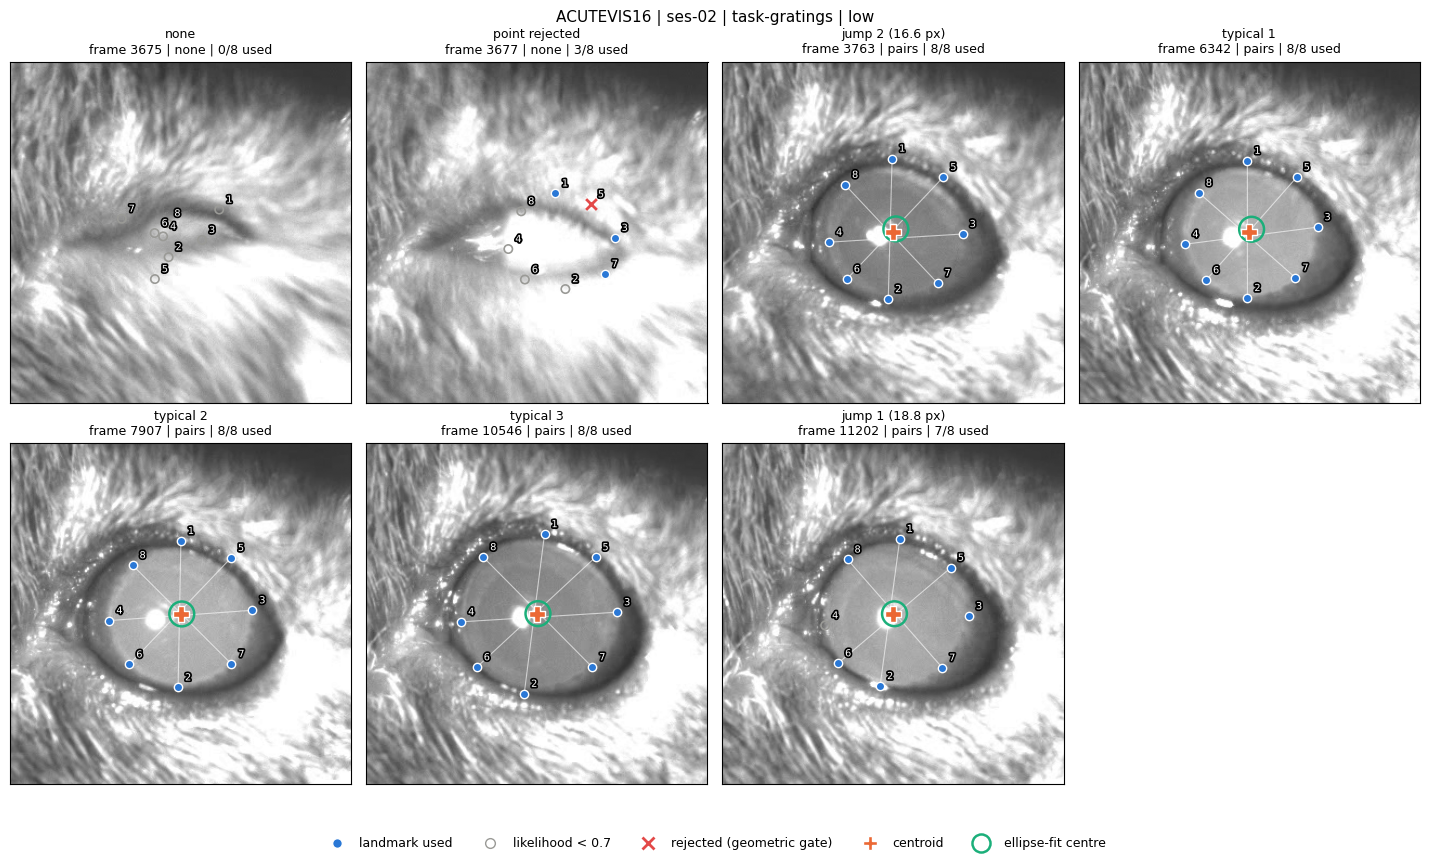

In [10]:
KEY = ("ACUTEVIS16", "ses-02", "task-gratings")
if KEY not in dlc:
    KEY = next(iter(dlc))
    print("KEY is not among the loaded sessions; using", KEY)
FRAMES = None            # e.g. [100, 2500, 7000]; None = automatic selection
SEED = 0


def pick_frames(df, n_typical=3, n_jumps=2, seed=SEED):
    '''label -> frame index, covering typical, degraded and large-jump frames.'''
    rng = np.random.default_rng(seed)
    picks = {}

    def add(label, candidates):
        candidates = np.setdiff1d(candidates, list(picks.values()))
        if len(candidates):
            picks[label] = int(rng.choice(candidates))

    typical = np.flatnonzero((df.method == "pairs") & (df.n_used == 8))
    for i, t in enumerate(np.sort(rng.choice(typical, min(n_typical, len(typical)), replace=False))):
        picks[f"typical {i + 1}"] = int(t)
    for m in ["ellipse", "circle", "one_pair", "none"]:
        add(m, np.flatnonzero(df.method == m))
    rej = np.flatnonzero(df.n_rejected > 0)
    rej_pairs = np.intersect1d(rej, np.flatnonzero(df.method == "pairs"))
    add("point rejected", rej_pairs if len(rej_pairs) else rej)
    step = df.step_px.to_numpy()
    for i, t in enumerate(np.argsort(np.nan_to_num(step, nan=-1))[::-1][:n_jumps]):
        picks[f"jump {i + 1} ({step[t]:.1f} px)"] = int(t)
    return dict(sorted(picks.items(), key=lambda kv: kv[1]))


def read_frame(mp4, idx):
    '''Grayscale frame `idx` from the raw video, or None if unavailable.'''
    if mp4 is None or not Path(mp4).exists():
        return None
    cap = cv2.VideoCapture(str(mp4))
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ok, frame = cap.read()
    cap.release()
    return cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY) if ok else None


C_USED, C_CENTRE, C_ELL, C_REJ, C_LOW = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#9a9a96"
HALO = [pe.withStroke(linewidth=2.5, foreground="black")]


def draw_frame(ax, key, t, title=""):
    d, df = dlc[key], centroids.loc[key]
    xy, used, rejected, valid = d["xy"][t], d["used"][t], d["rejected"][t], d["valid"][t]
    row = df.iloc[t]

    img = read_frame(sessions.loc[key, "mp4"], t)
    if img is not None:
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    else:
        ax.set_facecolor("#3a3a38")          # raw video not reachable (D: offline): landmarks only

    for j, (a, b) in enumerate(OPPOSITE_PAIRS):
        if used[a] and used[b]:
            ax.plot(xy[[a, b], 0], xy[[a, b], 1], color="white", lw=0.8, alpha=0.6)
    ax.scatter(*xy[used].T, s=36, color=C_USED, edgecolor="white", linewidth=1, zorder=3)
    ax.scatter(*xy[~valid].T, s=36, facecolor="none", edgecolor=C_LOW, linewidth=1.2, zorder=3)
    ax.scatter(*xy[rejected].T, s=60, marker="x", color=C_REJ, linewidth=2, zorder=4)
    for k in range(8):
        ax.annotate(str(k + 1), xy[k], xytext=(5, 5), textcoords="offset points",
                    color="white", fontsize=7, path_effects=HALO)
    if np.isfinite(row.ell_cx):
        ax.scatter(row.ell_cx, row.ell_cy, s=320, facecolor="none", edgecolor=C_ELL, linewidth=1.8, zorder=5)
    if np.isfinite(row.cx):
        ax.scatter(row.cx, row.cy, s=140, marker="P", color=C_CENTRE, edgecolor="white", linewidth=1, zorder=6)

    # crop around the pupil
    radius = np.nanmedian(df[[f"d_{n}_px" for n in PAIR_NAMES]].to_numpy()) / 2
    cx = row.cx if np.isfinite(row.cx) else np.nanmedian(df.cx)
    cy = row.cy if np.isfinite(row.cy) else np.nanmedian(df.cy)
    half = 2.4 * radius
    ax.set_xlim(cx - half, cx + half)
    ax.set_ylim(cy + half, cy - half)          # image y points down
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"{title}\nframe {t} | {row.method} | {row.n_used}/8 used", fontsize=9)


picks = pick_frames(centroids.loc[KEY]) if FRAMES is None else {f"frame {t}": t for t in FRAMES}
ncol = 4
nrow = int(np.ceil(len(picks) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.6 * ncol, 4.3 * nrow), squeeze=False)
for ax, (label, t) in zip(axes.flat, picks.items()):
    draw_frame(ax, KEY, t, label)
for ax in axes.flat[len(picks):]:
    ax.axis("off")

handles = [
    plt.Line2D([], [], ls="", marker="o", ms=7, color=C_USED, mec="white", label="landmark used"),
    plt.Line2D([], [], ls="", marker="o", ms=7, mfc="none", mec=C_LOW, label=f"likelihood < {P_CUTOFF}"),
    plt.Line2D([], [], ls="", marker="x", ms=8, mew=2, color=C_REJ, label="rejected (geometric gate)"),
    plt.Line2D([], [], ls="", marker="P", ms=10, color=C_CENTRE, mec="white", label="centroid"),
    plt.Line2D([], [], ls="", marker="o", ms=13, mfc="none", mec=C_ELL, mew=1.8, label="ellipse-fit centre"),
]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(" | ".join(KEY) + f" | {sessions.loc[KEY, 'condition']}", fontsize=11)
fig.tight_layout(rect=(0, 0.04, 1, 1), h_pad=2.0)
plt.show()

Centroid trace for the same session, with the frames above marked, to show where each check frame sits in the
recording. x and y are plotted separately because they are different measures. The time axis is frame index for now.

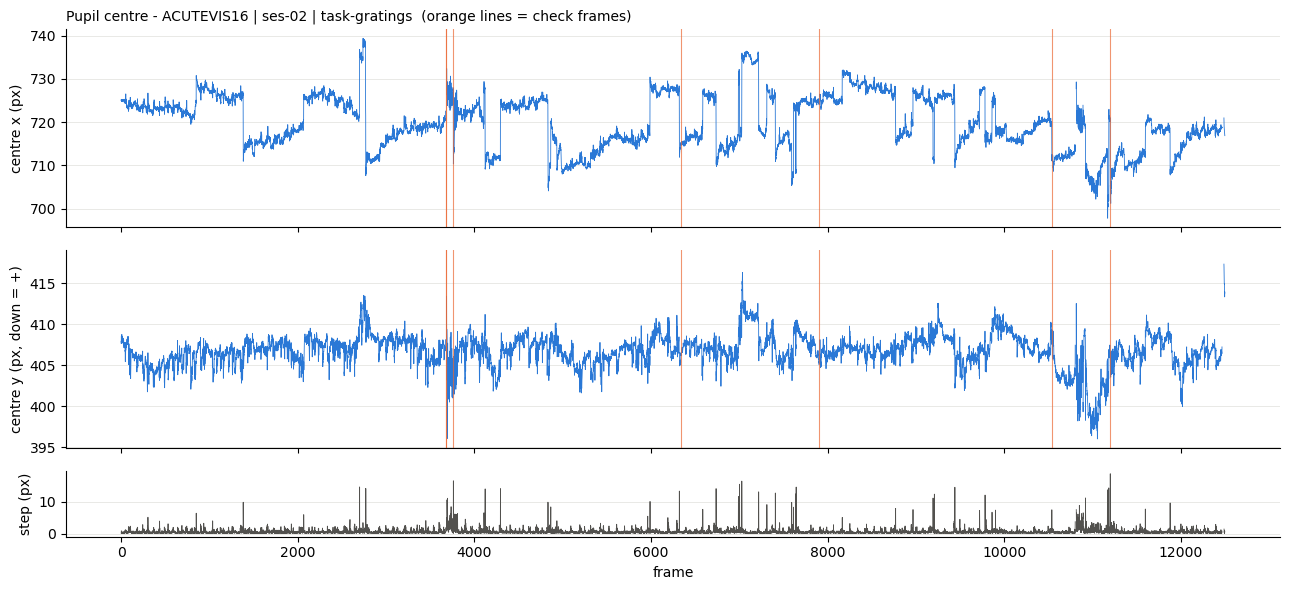

In [11]:
df = centroids.loc[KEY]
fig, axes = plt.subplots(3, 1, figsize=(13, 6), sharex=True, gridspec_kw={"height_ratios": [3, 3, 1]})
for ax, col, lab in zip(axes[:2], ["cx", "cy"], ["centre x (px)", "centre y (px, down = +)"]):
    ax.plot(df.index, df[col], color=C_USED, lw=0.6)
    ax.set_ylabel(lab)
    for t in picks.values():
        ax.axvline(t, color=C_CENTRE, lw=0.8, alpha=0.7)
axes[2].plot(df.index, df.step_px, color="#52514e", lw=0.6)
axes[2].set_ylabel("step (px)")
axes[2].set_xlabel("frame")
for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e5e5e2", lw=0.6)
axes[0].set_title(f"Pupil centre - {' | '.join(KEY)}  (orange lines = check frames)", fontsize=10, loc="left")
fig.tight_layout()
plt.show()

## 4. Save everything to C: (`pupil_centroids.pkl`)

One pickle with all the inputs and outputs of this analysis, so it can be recreated or continued without D:.
It's written only when all sessions are loaded (no `TASKS` / `SUBJECTS` / `CONDITIONS` filter). An existing file is
kept unless `OVERWRITE_CACHE = True`, e.g. after changing the centroid method.

| key | contents |
|---|---|
| `"sessions"` | index `(subject, session, task)`: `condition`, recording `stamp`, DLC `project`, source `h5` / `mp4` paths, `n_frames` |
| `"landmarks"` | raw DLC output, index `(subject, session, task, frame)`, columns `(landmark 1-8, x / y / likelihood)` |
| `"centroids"` | the `centroids` table above (centre, step, method, point counts, 4 diameters, `diameter_mm`, ellipse check) |
| `"qc"` | the per-session `qc` table |
| `"params"` | cutoffs, px/mm, landmark layout, opposite pairs, source paths, creation time |
| `"readme"` | this description, as text |

```python
cache = pd.read_pickle(r"C:\Projects\ACUTEVIS\pupil_centroids.pkl")
centroids = cache["centroids"]
```

In [12]:
OVERWRITE_CACHE = False


def landmarks_table(dlc):
    '''Raw DLC landmarks as one long table: index (subject, session, task, frame), columns (landmark, coord).'''
    per_session = {
        key: pd.DataFrame(np.concatenate([d["xy"], d["lk"][..., None]], axis=2).reshape(len(d["xy"]), -1),
                          columns=LANDMARK_COLUMNS)
        for key, d in dlc.items()
    }
    return pd.concat(per_session, names=["subject", "session", "task", "frame"]).sort_index()


CACHE_README = '''ACUTEVIS pupil centroids, from DeepLabCut pupil landmarks (8 points per frame).
Made by sipelab_scripts/pupil_saccades.ipynb.

sessions  : index (subject, session, task); condition (baseline/saline/low/high), stamp, project, h5, mp4, n_frames.
            Session number does NOT equal condition across cohorts, so use `condition`.
landmarks : raw DLC output. Index (subject, session, task, frame); columns (landmark 1-8, x/y/likelihood).
            Pixels, x right, y DOWN. Landmarks: 1 top, 2 bottom, 3 right, 4 left, 5 upper-right,
            6 lower-left, 7 lower-right, 8 upper-left. Opposite pairs (1,2) (3,4) (5,6) (7,8).
centroids : index (subject, session, task, frame). cx, cy = pupil centre (px), the mean of the usable
            opposite-pair midpoints (method == 'pairs'), with ellipse / circle / one_pair fallbacks and NaN
            for 'none'. step_px = displacement since the previous frame. d_*_px = the 4 pair diameters;
            diameter_mm = their mean / px_per_mm. ell_cx, ell_cy = independent ellipse-fit centre (cross-check).
qc        : per-session summary of centroids.
params    : settings used.
Frames are video frame numbers; they are not yet aligned to the dataqueue/suite2p time axis.
'''

if len(sessions) < len(all_sessions):
    print(f"not saving: only {len(sessions)} of {len(all_sessions)} sessions are loaded (filters are set)")
elif CACHE_PATH.exists() and not OVERWRITE_CACHE:
    print(f"{CACHE_PATH} already exists; set OVERWRITE_CACHE = True to replace it")
else:
    cache = {
        "readme": CACHE_README,
        "params": {
            "created": pd.Timestamp.now().isoformat(timespec="seconds"),
            "p_cutoff": P_CUTOFF, "px_per_mm": PX_PER_MM, "radial_tol": RADIAL_TOL,
            "landmark_labels": LANDMARK_LABELS, "nominal_angle_deg": NOMINAL_ANGLE.tolist(),
            "opposite_pairs": OPPOSITE_PAIRS, "pair_names": PAIR_NAMES,
            "condition_order": CONDITION_ORDER, "methods": METHODS,
            "dlc_root": str(DLC_ROOT), "dlc_projects": DLC_PROJECTS, "data_root": str(DATA_ROOT),
            "pandas_version": pd.__version__,
        },
        "sessions": all_sessions.assign(n_frames=pd.Series({k: len(d["xy"]) for k, d in dlc.items()})),
        "landmarks": landmarks_table(dlc),
        "centroids": centroids,
        "qc": qc,
    }
    tmp = CACHE_PATH.with_suffix(".tmp")
    pd.to_pickle(cache, tmp)
    tmp.replace(CACHE_PATH)
    print(f"wrote {CACHE_PATH} ({CACHE_PATH.stat().st_size / 1e6:.0f} MB): "
          f"{len(cache['sessions'])} sessions, {len(cache['landmarks']):,} frames")
    del cache

wrote C:\Projects\ACUTEVIS\pupil_centroids.pkl (348 MB): 88 sessions, 1,100,083 frames


## Next steps (not done yet)

- **Time axis:** the DLC frames index the ThorCam video. Map them to seconds with the dataqueue `thorcam` rows,
  as datakit does (`time_basis = 'dataqueue'`), so the centroid lines up with suite2p and psychopy events.
  The camera runs at ~20 Hz with jittered dt, so velocity must use real dt.
- **Units:** px → mm (`/ PX_PER_MM`) → degrees of eye rotation, which needs an eye-radius assumption (mouse ≈ 1.6 mm).
- **Saccade detection:** threshold the centre velocity, using only frames with `method == "pairs"`, and exclude
  frames next to `none` gaps (blink edges).